# Chapter 1 — Anatomy of an Agent

Every agent, in every framework, is the same four components:

1. **Model** — the reasoning engine that decides what to do next.
2. **Tools** — the registry of things it can actually do.
3. **Memory** — the state it carries between steps.
4. **Orchestrator** — the loop that ties them together.

This notebook builds a working agent with no framework, so the four parts are
visible in plain Python. It triages one security alert: a burst of failed logins
followed by a success — a possible account takeover.

**Nothing to install, nothing to clone.** Every cell runs on the Python standard
library alone. Run them in order.


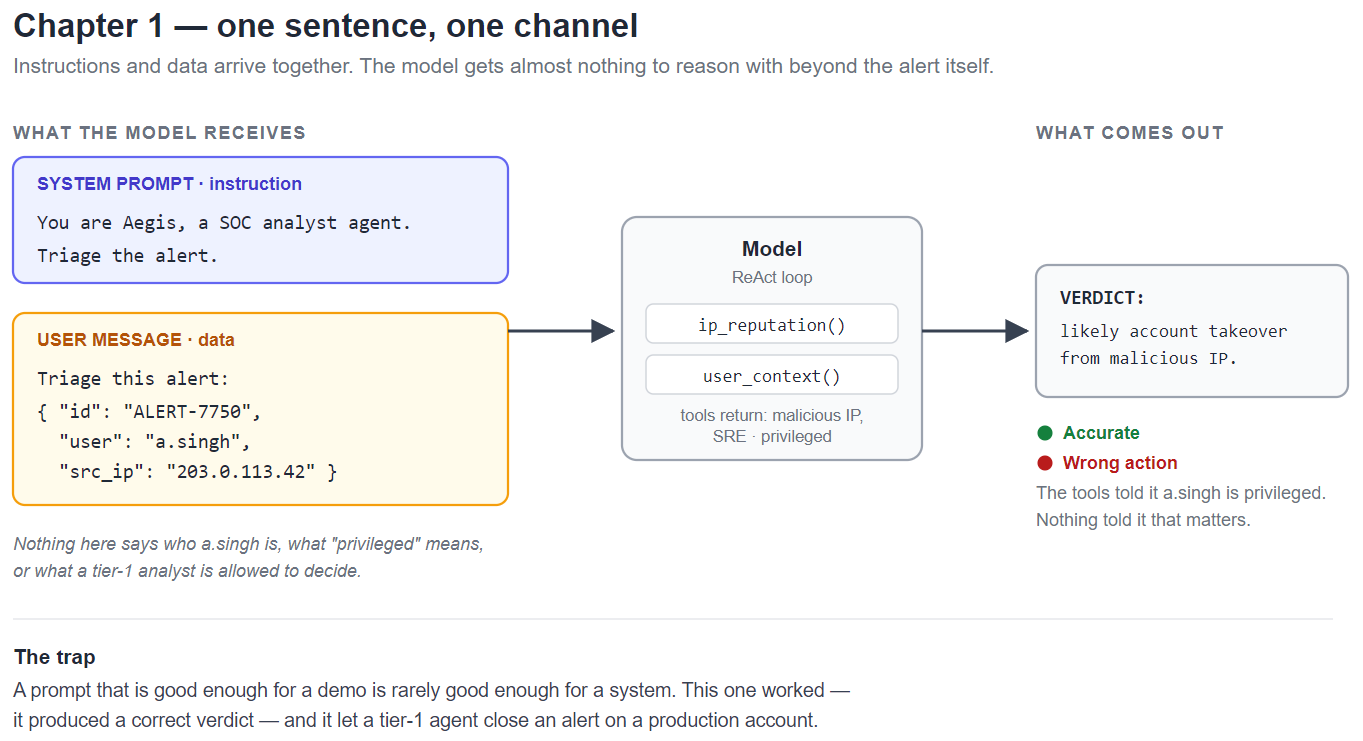

## The environment the agent works in

A security agent needs a world to investigate. Here it is: a few log lines and a
threat-intelligence table. In production these are API calls; the agent cannot tell
the difference, which is precisely why they sit behind tools.


In [1]:
import json

LOGS = [
    {"ts": "09:12:04", "event": "auth_fail", "user": "j.okafor", "src_ip": "203.0.113.42"},
    {"ts": "09:12:19", "event": "auth_fail", "user": "j.okafor", "src_ip": "203.0.113.42"},
    {"ts": "09:12:41", "event": "auth_fail", "user": "j.okafor", "src_ip": "203.0.113.42"},
    {"ts": "09:13:02", "event": "auth_success", "user": "j.okafor", "src_ip": "203.0.113.42"},
    {"ts": "09:31:55", "event": "file_download", "user": "j.okafor", "bytes": 8400000},
]

REPUTATION = {
    "203.0.113.42": {"score": 92, "verdict": "malicious",
                     "categories": ["bruteforce", "c2"], "last_seen": "2026-03-01"},
}

ALERT = {
    "id": "ALERT-7731",
    "rule": "Multiple failed logins followed by success",
    "user": "j.okafor",
    "src_ip": "203.0.113.42",
    "severity_hint": "high",
}

print(json.dumps(ALERT, indent=2))


{
  "id": "ALERT-7731",
  "rule": "Multiple failed logins followed by success",
  "user": "j.okafor",
  "src_ip": "203.0.113.42",
  "severity_hint": "high"
}


## Component 2 — Tools

A tool is an ordinary function. A tool *registry* is a dictionary mapping names to
those functions, and a *schema* describes each one to the model, so it knows what
it may call and with which arguments.

Aegis starts with two tools, both read-only. An agent that can only read can
embarrass you; an agent that can write can hurt you. Chapter 11 returns to this.


In [2]:
def search_logs(query: str, window: str = "1h") -> str:
    """Search SIEM logs. `query` matches an event type or a username."""
    q = query.lower()
    hits = [l for l in LOGS
            if q in l["event"].lower() or q in l.get("user", "").lower()]
    return json.dumps({"count": len(hits), "results": hits})


def ip_reputation(ip: str) -> str:
    """Look up an IP's threat-intel reputation: score, verdict, categories."""
    rep = REPUTATION.get(ip, {"score": 0, "verdict": "unknown", "categories": []})
    return json.dumps({"ip": ip, **rep})


TOOL_REGISTRY = {
    "search_logs": search_logs,
    "ip_reputation": ip_reputation,
}

TOOL_SCHEMAS = [
    {"type": "function", "function": {
        "name": "search_logs",
        "description": "Search SIEM logs by event type or username.",
        "parameters": {"type": "object",
                       "properties": {"query": {"type": "string"},
                                      "window": {"type": "string"}},
                       "required": ["query"]}}},
    {"type": "function", "function": {
        "name": "ip_reputation",
        "description": "Look up threat-intel reputation for an IP address.",
        "parameters": {"type": "object",
                       "properties": {"ip": {"type": "string"}},
                       "required": ["ip"]}}},
]


def call_tool(name: str, args: dict) -> str:
    fn = TOOL_REGISTRY.get(name)
    if fn is None:
        return json.dumps({"error": f"unknown tool: {name}"})
    return fn(**args)


for schema in TOOL_SCHEMAS:
    fn = schema["function"]
    print(f'{fn["name"]:15} required args: {fn["parameters"]["required"]}')


search_logs     required args: ['query']
ip_reputation   required args: ['ip']


## Component 1 — Model

The model decides what to do next: call a tool, or stop and answer. It returns one
of those two things and nothing else.

Below is a **mock** model — a deterministic stand-in that always makes the same
decisions. That determinism is a feature: you can watch the control flow without a
real model's variability muddying it. The last section swaps in a real model, and
the loop does not change by a single line. That interchangeability is the seam the
whole book is built on.


In [3]:
from dataclasses import dataclass, field


@dataclass
class ToolCall:
    name: str
    args: dict


@dataclass
class ModelResponse:
    """Either `text` is set (a final answer), or `tool_calls` is non-empty."""
    text: str = ""
    tool_calls: list = field(default_factory=list)

    @property
    def is_final(self) -> bool:
        return not self.tool_calls


class MockModel:
    """A deterministic stand-in. It reads memory and decides: if the source IP has
    not been checked yet, check it; otherwise, conclude."""

    name = "mock"

    def chat(self, messages: list, tools: list) -> ModelResponse:
        already_used_a_tool = any(m["role"] == "tool" for m in messages)
        if not already_used_a_tool:
            return ModelResponse(tool_calls=[
                ToolCall("ip_reputation", {"ip": ALERT["src_ip"]})
            ])
        return ModelResponse(text="Investigation complete. See structured findings.")


model = MockModel()
print("model tier:", model.name)


model tier: mock


## Component 3 — Memory

At this level, memory is a list of messages the model re-reads each turn. That is
all "memory" means until Chapter 5, which introduces the other three types:
episodic, semantic, and procedural.


In [4]:
def new_memory(alert: dict) -> list:
    return [
        {"role": "system", "content":
            "You are Aegis, a SOC triage agent. Use tools to investigate an alert, "
            "then state a one-line verdict. Do not fabricate facts."},
        {"role": "user", "content": f"Triage this alert: {json.dumps(alert)}"},
    ]


memory = new_memory(ALERT)
for message in memory:
    print(f'{message["role"]:8} {message["content"][:70]}')


system   You are Aegis, a SOC triage agent. Use tools to investigate an alert, 
user     Triage this alert: {"id": "ALERT-7731", "rule": "Multiple failed login


## Component 4 — Orchestrator

The loop. Each turn, the model either requests a tool call or produces a final
answer. Tool results are appended to memory as observations, and the loop runs
again. That think-act-observe cycle is the ReAct pattern, and it is about twenty
lines of Python.

Note `max_steps`. An agent with tools and no bound is an unbounded actor, so the
loop's exit condition is a safety control, not a performance detail — and when the
budget runs out, the halt is *recorded* rather than hidden.


In [5]:
def run(alert: dict = None, max_steps: int = 5, verbose: bool = True) -> dict:
    alert = alert or ALERT
    memory = new_memory(alert)      # COMPONENT 3
    trajectory = []

    for step in range(max_steps):   # COMPONENT 4
        response = model.chat(memory, TOOL_SCHEMAS)     # COMPONENT 1

        if response.is_final:       # termination: the model has a verdict
            memory.append({"role": "assistant", "content": response.text})
            trajectory.append(("final", response.text))
            if verbose:
                print(f"  step {step}: FINAL - {response.text}")
            break

        for call in response.tool_calls:                    # act
            observation = call_tool(call.name, call.args)   # COMPONENT 2
            memory.append({"role": "assistant",
                           "content": f"[call] {call.name}({json.dumps(call.args)})"})
            memory.append({"role": "tool", "content": observation})   # observe
            trajectory.append((call.name, observation))
            if verbose:
                print(f"  step {step}: {call.name}({call.args}) -> {observation[:60]}")
    else:
        trajectory.append(("halt", "max_steps reached"))

    return {"model": model.name, "trajectory": trajectory, "memory": memory}


print("agent defined")


agent defined


## Run it


In [6]:
result = run()

print()
print("model tier:", result["model"])
print("steps taken:", len(result["trajectory"]))


  step 0: ip_reputation({'ip': '203.0.113.42'}) -> {"ip": "203.0.113.42", "score": 92, "verdict": "malicious", 
  step 1: FINAL - Investigation complete. See structured findings.

model tier: mock
steps taken: 2


Expected output:

```
  step 0: ip_reputation({'ip': '203.0.113.42'}) -> {"ip": "203.0.113.42", "score": 92, "verdict": "malicious",
  step 1: FINAL - Investigation complete. See structured findings.

model tier: mock
steps taken: 2
```

The agent looked up the source IP, found it malicious, and concluded. Two steps,
four components, no framework.

The mock model is deterministic, so your output matches this exactly.


## Inspect what the agent carried

Memory grew as the loop ran. This list is the agent's entire state — readable,
printable, and (by Chapter 10) traceable.


In [7]:
for message in result["memory"]:
    print(f'{message["role"]:10} {message["content"][:70]}')


system     You are Aegis, a SOC triage agent. Use tools to investigate an alert, 
user       Triage this alert: {"id": "ALERT-7731", "rule": "Multiple failed login
assistant  [call] ip_reputation({"ip": "203.0.113.42"})
tool       {"ip": "203.0.113.42", "score": 92, "verdict": "malicious", "categorie
assistant  Investigation complete. See structured findings.


## Bound the loop

Set the step budget to 1 and the agent cannot finish. Note that the halt appears in
the trajectory: a silent truncation would be the bug.


In [8]:
starved = run(max_steps=1, verbose=False)

for name, observation in starved["trajectory"]:
    print(f'{name:15} {observation[:60]}')


ip_reputation   {"ip": "203.0.113.42", "score": 92, "verdict": "malicious", 
halt            max_steps reached


## Add a tool

The orchestrator never names a specific tool. Register a third one and the loop
picks it up with no change at all — because tools are data, not code paths.


In [9]:
def user_context(user: str) -> str:
    """Fetch an account's role, department, and privilege level."""
    directory = {
        "j.okafor": {"role": "Finance Analyst", "dept": "Finance", "privileged": False},
        "a.singh": {"role": "SRE", "dept": "Platform", "privileged": True},
    }
    return json.dumps({"user": user, **directory.get(user, {"role": "unknown"})})


TOOL_REGISTRY["user_context"] = user_context
TOOL_SCHEMAS.append({"type": "function", "function": {
    "name": "user_context",
    "description": "Fetch an account's role, department, and privilege level.",
    "parameters": {"type": "object",
                   "properties": {"user": {"type": "string"}},
                   "required": ["user"]}}})

print("tools now:", list(TOOL_REGISTRY))
print()
print(call_tool("user_context", {"user": "j.okafor"}))


tools now: ['search_logs', 'ip_reputation', 'user_context']

{"user": "j.okafor", "role": "Finance Analyst", "dept": "Finance", "privileged": false}


---

## What you built

A working agent in about forty lines: a model behind a swappable seam, a tool
registry, a memory list, and a bounded loop. Every framework in this book — and
every framework outside it — rearranges these same four parts.

Chapter 2 layers the system prompt and watches a single constraint change a verdict.
Chapter 3 gives the agent tools properly, three different ways: function calling,
OpenAPI, and MCP.

